In [1]:
from pathlib import Path
import json
import pandas as pd

from src.verifier.remove_random_visible_objects import remove_random_visible_objects
from src.verifier.rotate_random_visible_objects import rotate_random_visible_objects
from src.verifier.scale_random_visible_objects import scale_random_visible_objects
from src.verifier.translate_random_visible_objects import translate_random_visible_objects

from src.vlm_score import compute_vlm_score


In [ ]:
# target_dir = Path("../dataset_verifier_b")
# target_dir.mkdir(parents=True, exist_ok=True)

# for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset").iterdir():
#     if scene_dir.name.startswith("."):
#         continue
#     remove_random_visible_objects(scene_dir, target_dir / f"remove/{scene_dir.name}")
#     rotate_random_visible_objects(scene_dir, target_dir / f"rotate/{scene_dir.name}")
#     scale_random_visible_objects(scene_dir, target_dir / f"scale/{scene_dir.name}")
#     translate_random_visible_objects(scene_dir, target_dir / f"translate/{scene_dir.name}")


In [10]:
placement_scores = {}

for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_b/translate").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="placement",
    )

    placement_scores[scene_dir.name] = score

In [18]:
count_scores_a = {}
count_scores_b = {}

for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_a/remove").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="count",
    )

    count_scores_a[scene_dir.name] = score


for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_b/remove").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="count",
    )

    count_scores_b[scene_dir.name] = score

In [20]:
with open("count_scores_a.json", "w") as f:
    json.dump(count_scores_a, f, indent=2)

with open("count_scores_b.json", "w") as f:
    json.dump(count_scores_b, f, indent=2)

In [21]:
rotation_scores_a = {}
rotation_scores_b = {}

for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_a/rotate").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="rotation",
    )

    rotation_scores_a[scene_dir.name] = score


for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_b/rotate").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="rotation",
    )

    rotation_scores_b[scene_dir.name] = score


with open("rotation_scores_a.json", "w") as f:
    json.dump(rotation_scores_a, f, indent=2)

with open("rotation_scores_b.json", "w") as f:
    json.dump(rotation_scores_b, f, indent=2)

In [22]:
scale_scores_a = {}
scale_scores_b = {}

for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_a/scale").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="scale",
    )

    scale_scores_a[scene_dir.name] = score


for scene_dir in Path("/Users/jonathansickert/git/3DFrontBench/dataset_verifier_b/scale").iterdir():
    if scene_dir.name.startswith("."):
        continue

    score = compute_vlm_score(
        target_path=Path("/Users/jonathansickert/git/3DFrontBench/dataset") / scene_dir.name / "color.png",
        render_path=scene_dir / "color.png",
        score_type="scale",
    )

    scale_scores_b[scene_dir.name] = score


with open("scale_scores_a.json", "w") as f:
    json.dump(scale_scores_a, f, indent=2)

with open("scale_scores_b.json", "w") as f:
    json.dump(scale_scores_b, f, indent=2)

In [60]:
def populate_scores_df(
    json_file_a: str,
    json_file_b: str,
    dataset_name: str
) -> pd.DataFrame:
    
    def cmp_vlm_score(score_a: int, score_b: int):
        if score_a > score_b:
            return True
        
        return False
    
    def cmp_perturbation_score(score_a: float, score_b: float):
        if score_a < score_b:
            return True
        
        return False

    with open(json_file_a) as f:
        vlm_score_a = json.load(f)

    with open(json_file_b) as f:
        vlm_score_b = json.load(f)

    for scene_dir in Path(f"/Users/jonathansickert/git/3DFrontBench/dataset_verifier_a/{dataset_name}").iterdir():
        if scene_dir.name.startswith("."):
            continue
        with open(scene_dir / "score.json") as f:
            score = json.load(f)

        vlm_score_a[scene_dir.name]["score_perturbation"] = score["score"]

    for scene_dir in Path(f"/Users/jonathansickert/git/3DFrontBench/dataset_verifier_b/{dataset_name}").iterdir():
        if scene_dir.name.startswith("."):
            continue
        with open(scene_dir / "score.json") as f:
            score = json.load(f)

        vlm_score_b[scene_dir.name]["score_perturbation"] = score["score"]


    ab_rows = []
    for scene in sorted(vlm_score_a.keys()):
        vlm_a = vlm_score_a[scene]["score"]
        vlm_b = vlm_score_b[scene]["score"]

        perturbation_a = vlm_score_a[scene]["score_perturbation"]
        perturbation_b = vlm_score_b[scene]["score_perturbation"]

        verdict_a = cmp_vlm_score(vlm_a, vlm_b)
        verdict_b = cmp_perturbation_score(perturbation_a, perturbation_b)

        ab_rows.append(
            {
                "scene": scene,
                "vlm_a": vlm_a,
                "vlm_b": vlm_b,
                "perturbation_a": perturbation_a,
                "perturbation_b" : perturbation_b,
                "score_a_gt_b": verdict_a,
                "score_vlm_a_gt_b": verdict_b,
                "match": verdict_a == verdict_b,
            }
        )

    ab_df = pd.DataFrame(ab_rows).set_index("scene")
    return ab_df


In [61]:
placement_ab = populate_scores_df("placement_scores_a.json", "placement_scores_b.json", "translate")
agree = placement_ab["match"].sum()
total = len(placement_ab)
print(f"{agree}/{total} scenes agree ({agree / total:.1%})")

25/30 scenes agree (83.3%)


<Axes: xlabel='diff_vlm', ylabel='diff_perturbation'>

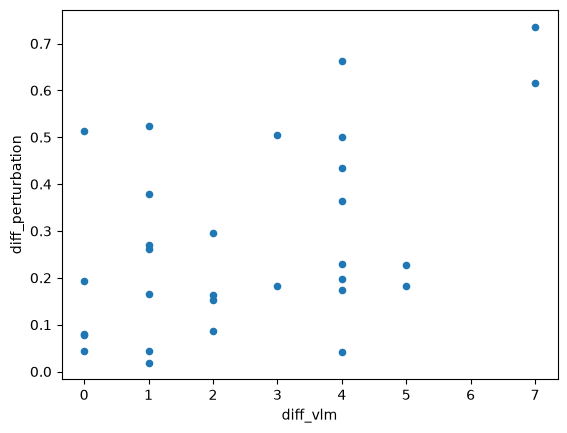

In [62]:
placement_ab["diff_vlm"] = abs(placement_ab["vlm_a"]-placement_ab["vlm_b"])
placement_ab["diff_perturbation"] = abs(placement_ab["perturbation_a"]-placement_ab["perturbation_b"])

placement_ab.plot.scatter("diff_vlm", "diff_perturbation")

<Axes: xlabel='vlm', ylabel='perturbation'>

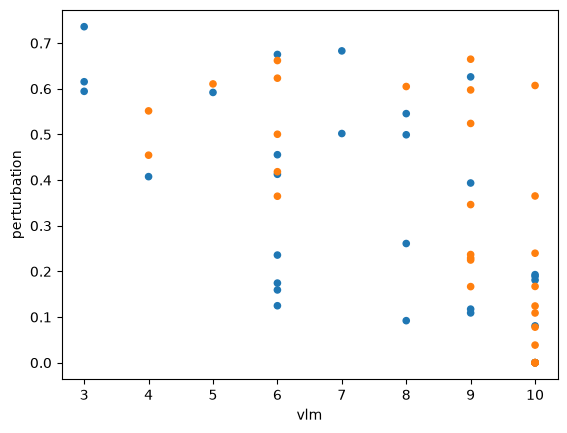

In [73]:
long_df = pd.concat([
    placement_ab[["vlm_a", "perturbation_a"]].rename(columns={"vlm_a": "vlm", "perturbation_a": "perturbation"}).assign(group="A"),
    placement_ab[["vlm_b", "perturbation_b"]].rename(columns={"vlm_b": "vlm", "perturbation_b": "perturbation"}).assign(group="B"),
])

long_df.plot.scatter(x="vlm", y="perturbation", c=long_df["group"].map({"A": "tab:blue", "B": "tab:orange"}))

In [64]:
count_ab = populate_scores_df("count_scores_a.json", "count_scores_b.json", "remove")
agree = count_ab["match"].sum()
total = len(count_ab)
print(f"{agree}/{total} scenes agree ({agree / total:.1%})")

24/30 scenes agree (80.0%)


<Axes: xlabel='VLM Count Score', ylabel='Perturbation Count Score'>

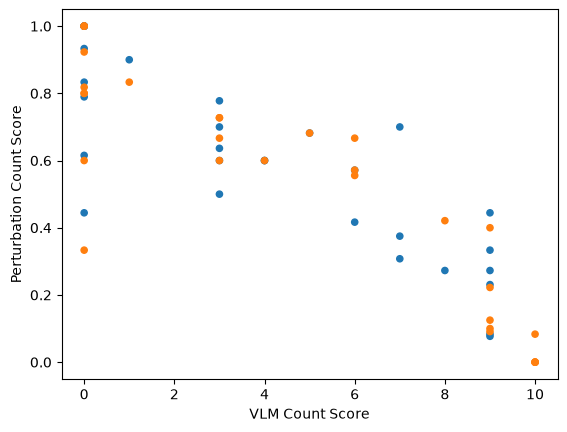

In [68]:
long_df = pd.concat([
    count_ab[["vlm_a", "perturbation_a"]].rename(columns={"vlm_a": "vlm", "perturbation_a": "perturbation"}).assign(group="A"),
    count_ab[["vlm_b", "perturbation_b"]].rename(columns={"vlm_b": "vlm", "perturbation_b": "perturbation"}).assign(group="B"),
])

long_df.plot.scatter(x="vlm", y="perturbation", c=long_df["group"].map({"A": "tab:blue", "B": "tab:orange"}), xlabel="VLM Count Score", ylabel="Perturbation Count Score")

<Axes: xlabel='diff_vlm', ylabel='diff_perturbation'>

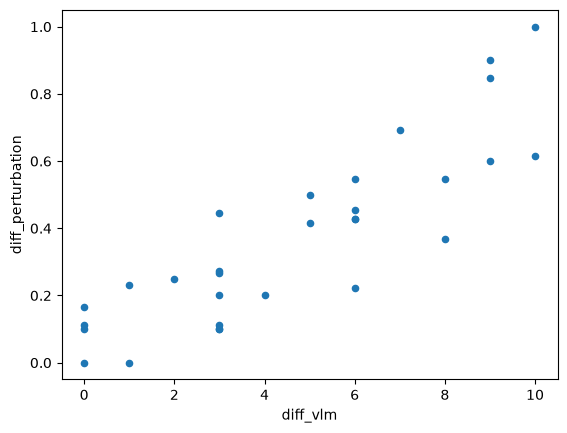

In [66]:
count_ab["diff_vlm"] = abs(count_ab["vlm_a"]-count_ab["vlm_b"])
count_ab["diff_perturbation"] = abs(count_ab["perturbation_a"]-count_ab["perturbation_b"])

count_ab.plot.scatter("diff_vlm", "diff_perturbation")

In [69]:
scale_ab = populate_scores_df("scale_scores_a.json", "scale_scores_b.json", "scale")
agree = scale_ab["match"].sum()
total = len(scale_ab)
print(f"{agree}/{total} scenes agree ({agree / total:.1%})")

17/30 scenes agree (56.7%)


<Axes: xlabel='diff_vlm', ylabel='diff_perturbation'>

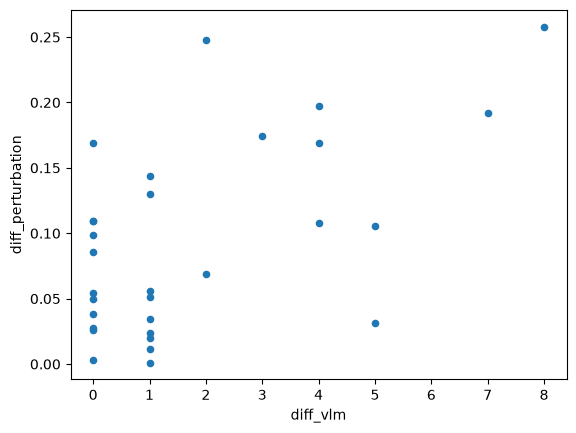

In [70]:
scale_ab["diff_vlm"] = abs(scale_ab["vlm_a"]-scale_ab["vlm_b"])
scale_ab["diff_perturbation"] = abs(scale_ab["perturbation_a"]-scale_ab["perturbation_b"])

scale_ab.plot.scatter("diff_vlm", "diff_perturbation")

<Axes: xlabel='VLM Scale Score', ylabel='Perturbation Scale Score'>

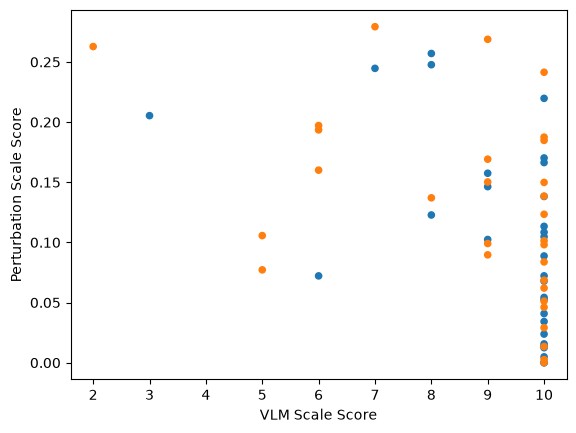

In [72]:
long_df = pd.concat([
    scale_ab[["vlm_a", "perturbation_a"]].rename(columns={"vlm_a": "vlm", "perturbation_a": "perturbation"}).assign(group="A"),
    scale_ab[["vlm_b", "perturbation_b"]].rename(columns={"vlm_b": "vlm", "perturbation_b": "perturbation"}).assign(group="B"),
])

long_df.plot.scatter(x="vlm", y="perturbation", c=long_df["group"].map({"A": "tab:blue", "B": "tab:orange"}), xlabel="VLM Scale Score", ylabel="Perturbation Scale Score")

In [54]:
rotation_ab = populate_scores_df("rotation_scores_a.json", "rotation_scores_b.json", "rotate")
agree = rotation_ab["match"].sum()
total = len(rotation_ab)
print(f"{agree}/{total} scenes agree ({agree / total:.1%})")

14/30 scenes agree (46.7%)


<Axes: xlabel='vlm', ylabel='perturbation'>

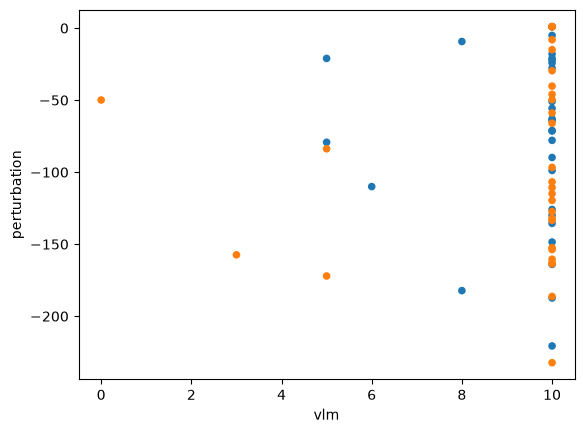

In [40]:
long_df = pd.concat([
    rotation_ab[["vlm_a", "perturbation_a"]].rename(columns={"vlm_a": "vlm", "perturbation_a": "perturbation"}).assign(group="A"),
    rotation_ab[["vlm_b", "perturbation_b"]].rename(columns={"vlm_b": "vlm", "perturbation_b": "perturbation"}).assign(group="B"),
])

long_df.plot.scatter(x="vlm", y="perturbation", c=long_df["group"].map({"A": "tab:blue", "B": "tab:orange"}))